In this project, you will visualize and make calculations from medical examination data using `matplotlib`, `seaborn`, and `pandas`. The dataset values were collected during medical examinations.

In [96]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

Import the data from `medical_examination.csv` and assign it to the `df` variable.

In [97]:
df = pd.read_csv('medical_examination.csv')
df.head()

,id,age,sex,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


Add an `overweight` column to the data. To determine if a person is overweight, first calculate their BMI by dividing their weight in kilograms by the square of their height in meters. If that value is > 25 then the person is overweight. Use the value `0` for NOT overweight and the value `1` for overweight.

In [98]:
#Height is in cm, we must convert it to meters.
overweight = (df['weight'] / ((df['height'] / 100) ** 2)) > 25
overweight = overweight.astype(int)

df['overweight'] = overweight

Normalize data by making `0` always good and `1` always bad. If the value of `cholesterol` or `gluc` is `1`, set the value to `0`. If the value is more than `1`, set the value to `1`.

In [99]:
df['cholesterol'] = (df['cholesterol'] > 1).astype(int)
df['gluc'] = (df['gluc'] > 1).astype(int)

In [100]:
df.head()

,id,age,sex,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,overweight
0,0,18393,2,168,62.0,110,80,0,0,0,0,1,0,0
1,1,20228,1,156,85.0,140,90,1,0,0,0,1,1,1
2,2,18857,1,165,64.0,130,70,1,0,0,0,0,1,0
3,3,17623,2,169,82.0,150,100,0,0,0,0,1,1,1
4,4,17474,1,156,56.0,100,60,0,0,0,0,0,0,0


Draw the Categorical Plot in the `draw_cat_plot` function.

Create a DataFrame for the cat plot using `pd.melt` with values from `cholesterol`, `gluc`, `smoke`, `alco`, `active`, and `overweight` in the `df_cat` variable.

Group and reformat the data in `df_cat` to split it by `cardio`. Show the counts of each feature. You will have to rename one of the columns for the `catplot` to work correctly.

Convert the data into `long` format and create a chart that shows the value counts of the categorical features using the following method provided by the seaborn library import: `sns.catplot()`.

Get the figure for the output and store it in the `fig` variable.

In [101]:
def draw_cat_plot(data):
  df_cat = pd.melt(data, id_vars=['cardio'], value_vars=['cholesterol', 'gluc', 'smoke', 'alco', 'active', 'overweight'])

  # Agrupamos por 'cardio', 'variable' y 'value', y contamos
  df_cat = df_cat.groupby(['cardio', 'variable', 'value']).size().reset_index(name='total')

  fig = sns.catplot(
    data=df_cat,
    kind='bar',
    x='variable',
    y='total',
    hue='value',
    col='cardio',
  ).fig

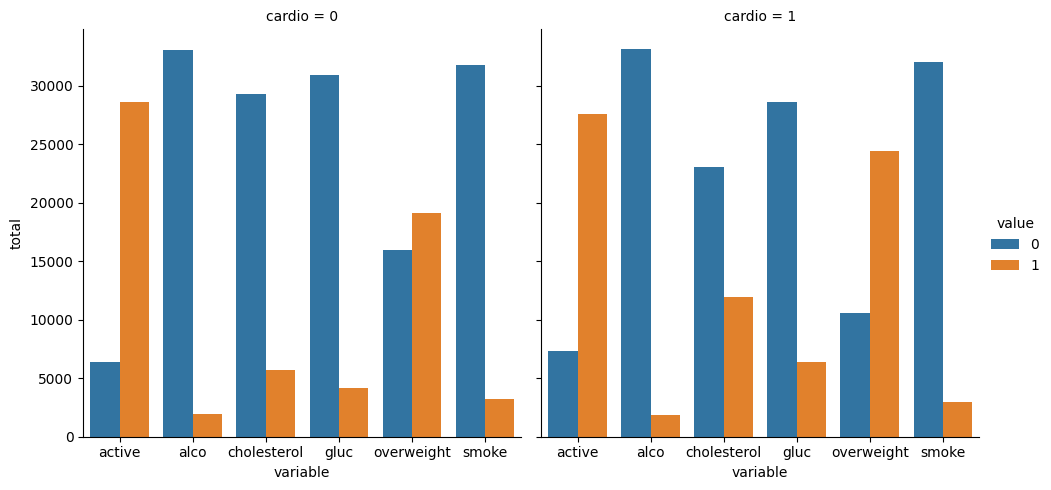

In [102]:
draw_cat_plot(df)

Draw the Heat Map in the `draw_heat_map` function.

Clean the data in the `df_heat` variable by filtering out the following patient segments that represent incorrect data:
diastolic pressure is higher than systolic (Keep the correct data with `(df['ap_lo'] <= df['ap_hi'])`)
height is less than the 2.5th percentile (Keep the correct data with `(df['height'] >= df['height'].quantile(0.025))`)

*   height is more than the 97.5th percentile
*   weight is less than the 2.5th percentile
*   weight is more than the 97.5th percentile

Calculate the correlation matrix and store it in the `corr` variable.

Generate a mask for the upper triangle and store it in the `mask` variable.

Set up the `matplotlib` figure.

Plot the correlation matrix using the method provided by the seaborn library import: `sns.heatmap()`.

In [103]:
def draw_heat_map(data):
  h_low = data['height'].quantile(0.025)
  h_high = data['height'].quantile(0.975)
  w_low = data['weight'].quantile(0.025)
  w_high = data['weight'].quantile(0.975)

  df_heat = data.query(
    'ap_lo <= ap_hi and '
    'height >= @h_low and height <= @h_high and '
    'weight >= @w_low and weight <= @w_high'
    )

  corr = df_heat.corr(numeric_only=True)
  mask = np.triu(np.ones_like(corr, dtype=bool))

  sns.heatmap(
        corr,
        mask=mask,
        annot=True,
        fmt=".1f",
        center=0,
        vmax=0.3,
        square=True,
        linewidths=0.5,
        cbar_kws={"shrink": 0.5}
  )

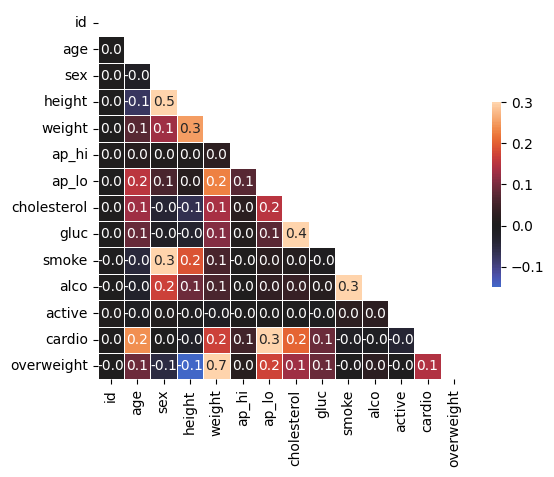

In [104]:
draw_heat_map(df)